# Seeds dataset — EDA и подготовка

Датасет **Seeds** (UCI): геометрические признаки зёрен пшеницы трёх сортов — *Kama (1), Rosa (2), Canadian (3)*.

**План:**
- Шаг 1. Загрузка библиотек
- Шаг 2. EDA: размеры, масштабы, пропуски, выбросы, распределения, корреляции
- Приведение признаков к одному масштабу (`StandardScaler`)
- Краткая фиксация находок

## Шаг 1. Загрузка библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("Библиотеки загружены")

Библиотеки загружены


## Шаг 2. EDA и подготовка

### 2.1 Импорт датасета

In [2]:
# Признаки seeds (UCI). Файл разделён пробелами/табами, без заголовка.
feature_names = [
    "area",            # площадь
    "perimeter",       # периметр
    "compactness",     # компактность = 4*pi*A / P^2
    "kernel_length",   # длина зерна
    "kernel_width",    # ширина зерна
    "asymmetry",       # коэффициент асимметрии
    "groove_length",   # длина бороздки
]

raw = pd.read_csv("seeds_dataset.txt", sep=r"\s+", header=None)
raw.columns = feature_names + ["class"]

df = raw.reset_index(drop=True)
df["class"] = df["class"].astype(int)

class_names = {1: "Kama", 2: "Rosa", 3: "Canadian"}
print("Размерность:", df.shape)
df.head()

Размерность: (210, 8)


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,class
0,15.260,14.840,0.871,5.763,3.312,2.221,5.220,1
1,14.880,14.570,0.881,5.554,3.333,1.018,4.956,1
2,14.290,14.090,0.905,5.291,3.337,2.699,4.825,1
3,13.840,13.940,0.895,5.324,3.379,2.259,4.805,1
4,16.140,14.990,0.903,5.658,3.562,1.355,5.175,1


In [3]:
feature_names_ru = {
    "area": "площадь",
    "perimeter": "периметр",
    "compactness": "компактность",
    "kernel_length": "длина зерна",
    "kernel_width": "ширина зерна",
    "asymmetry": "асимметрия",
    "groove_length": "длина бороздки",
}

### 2.2 Размеры, типы, масштабы, пропуски

In [4]:
print(f"Объектов (строк):   {df.shape[0]}")
print(f"Признаков (без class): {len(feature_names)}")
print(f"Размерность:        {df.shape}\n")

print("Типы данных:")
print(df.dtypes, "\n")

print("Пропуски по столбцам:")
print(df.isna().sum(), "\n")

print("Дубликаты строк:", df.duplicated().sum(), "\n")

print("Баланс классов:")
print(df["class"].map(class_names).value_counts())

Объектов (строк):   210
Признаков (без class): 7
Размерность:        (210, 8)

Типы данных:
area             float64
perimeter        float64
compactness      float64
kernel_length    float64
kernel_width     float64
asymmetry        float64
groove_length    float64
class              int32
dtype: object 

Пропуски по столбцам:
area             0
perimeter        0
compactness      0
kernel_length    0
kernel_width     0
asymmetry        0
groove_length    0
class            0
dtype: int64 

Дубликаты строк: 0 

Баланс классов:
class
Kama        70
Rosa        70
Canadian    70
Name: count, dtype: int64


In [5]:
# Статистика по признакам — обратите внимание на разный масштаб (min/max/std)
desc = df[feature_names].describe().T
desc["range"] = desc["max"] - desc["min"]
desc[["min", "max", "range", "mean", "std"]]

,min,max,range,mean,std
area,10.590,21.180,10.590,14.848,2.910
perimeter,12.410,17.250,4.840,14.559,1.306
compactness,0.808,0.918,0.110,0.871,0.024
kernel_length,4.899,6.675,1.776,5.629,0.443
kernel_width,2.630,4.033,1.403,3.259,0.378
asymmetry,0.765,8.456,7.691,3.700,1.504
groove_length,4.519,6.550,2.031,5.408,0.491


### 2.3 Распределения признаков

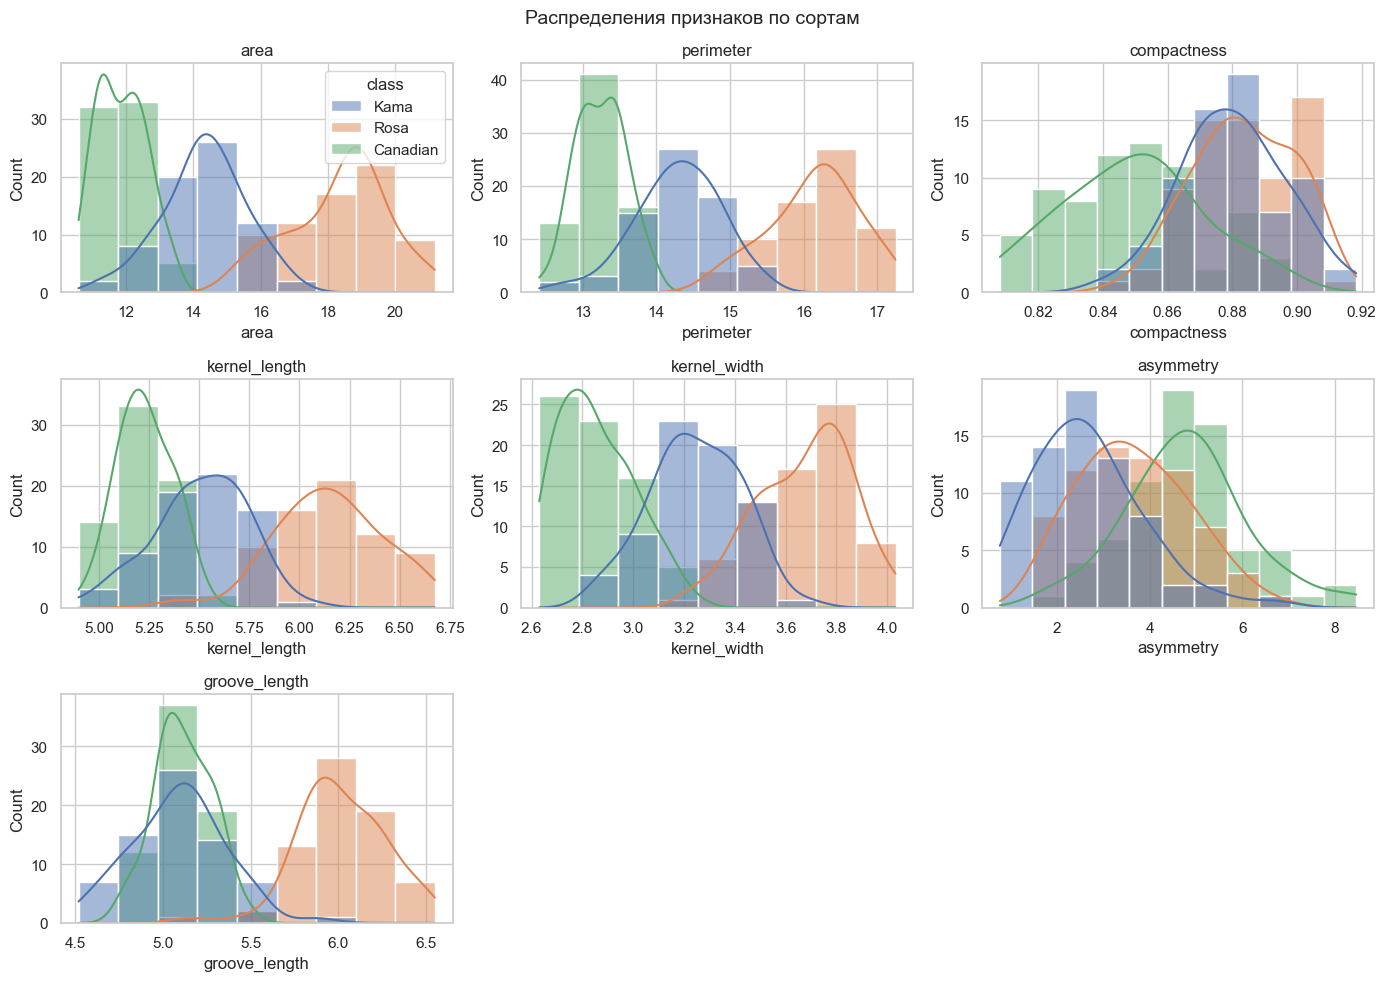

In [6]:
# Гистограммы распределений
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, feature_names):
    sns.histplot(data=df, x=col, hue=df["class"].map(class_names),
                 kde=True, ax=ax, legend=(col == feature_names[0]))
    ax.set_title(col)
for ax in axes.flat[len(feature_names):]:
    ax.axis("off")
fig.suptitle("Распределения признаков по сортам", fontsize=14)
fig.tight_layout()
plt.show()

**Вывод по распределениям:**
- Большинство признаков распределены близко к нормальному, без резких скосов; заметный правый хвост только у `asymmetry`.
- Сорт **Rosa (2)** явно крупнее по `area`, `perimeter`, `kernel_length` — отделяется почти по любому «размерному» признаку.
- **Kama (1)** и **Canadian (3)** сильно перекрываются по размерам; различать их помогают `compactness` и `asymmetry` (у Canadian зёрна менее компактные).

### 2.3.1 Парные диаграммы (pairplot)

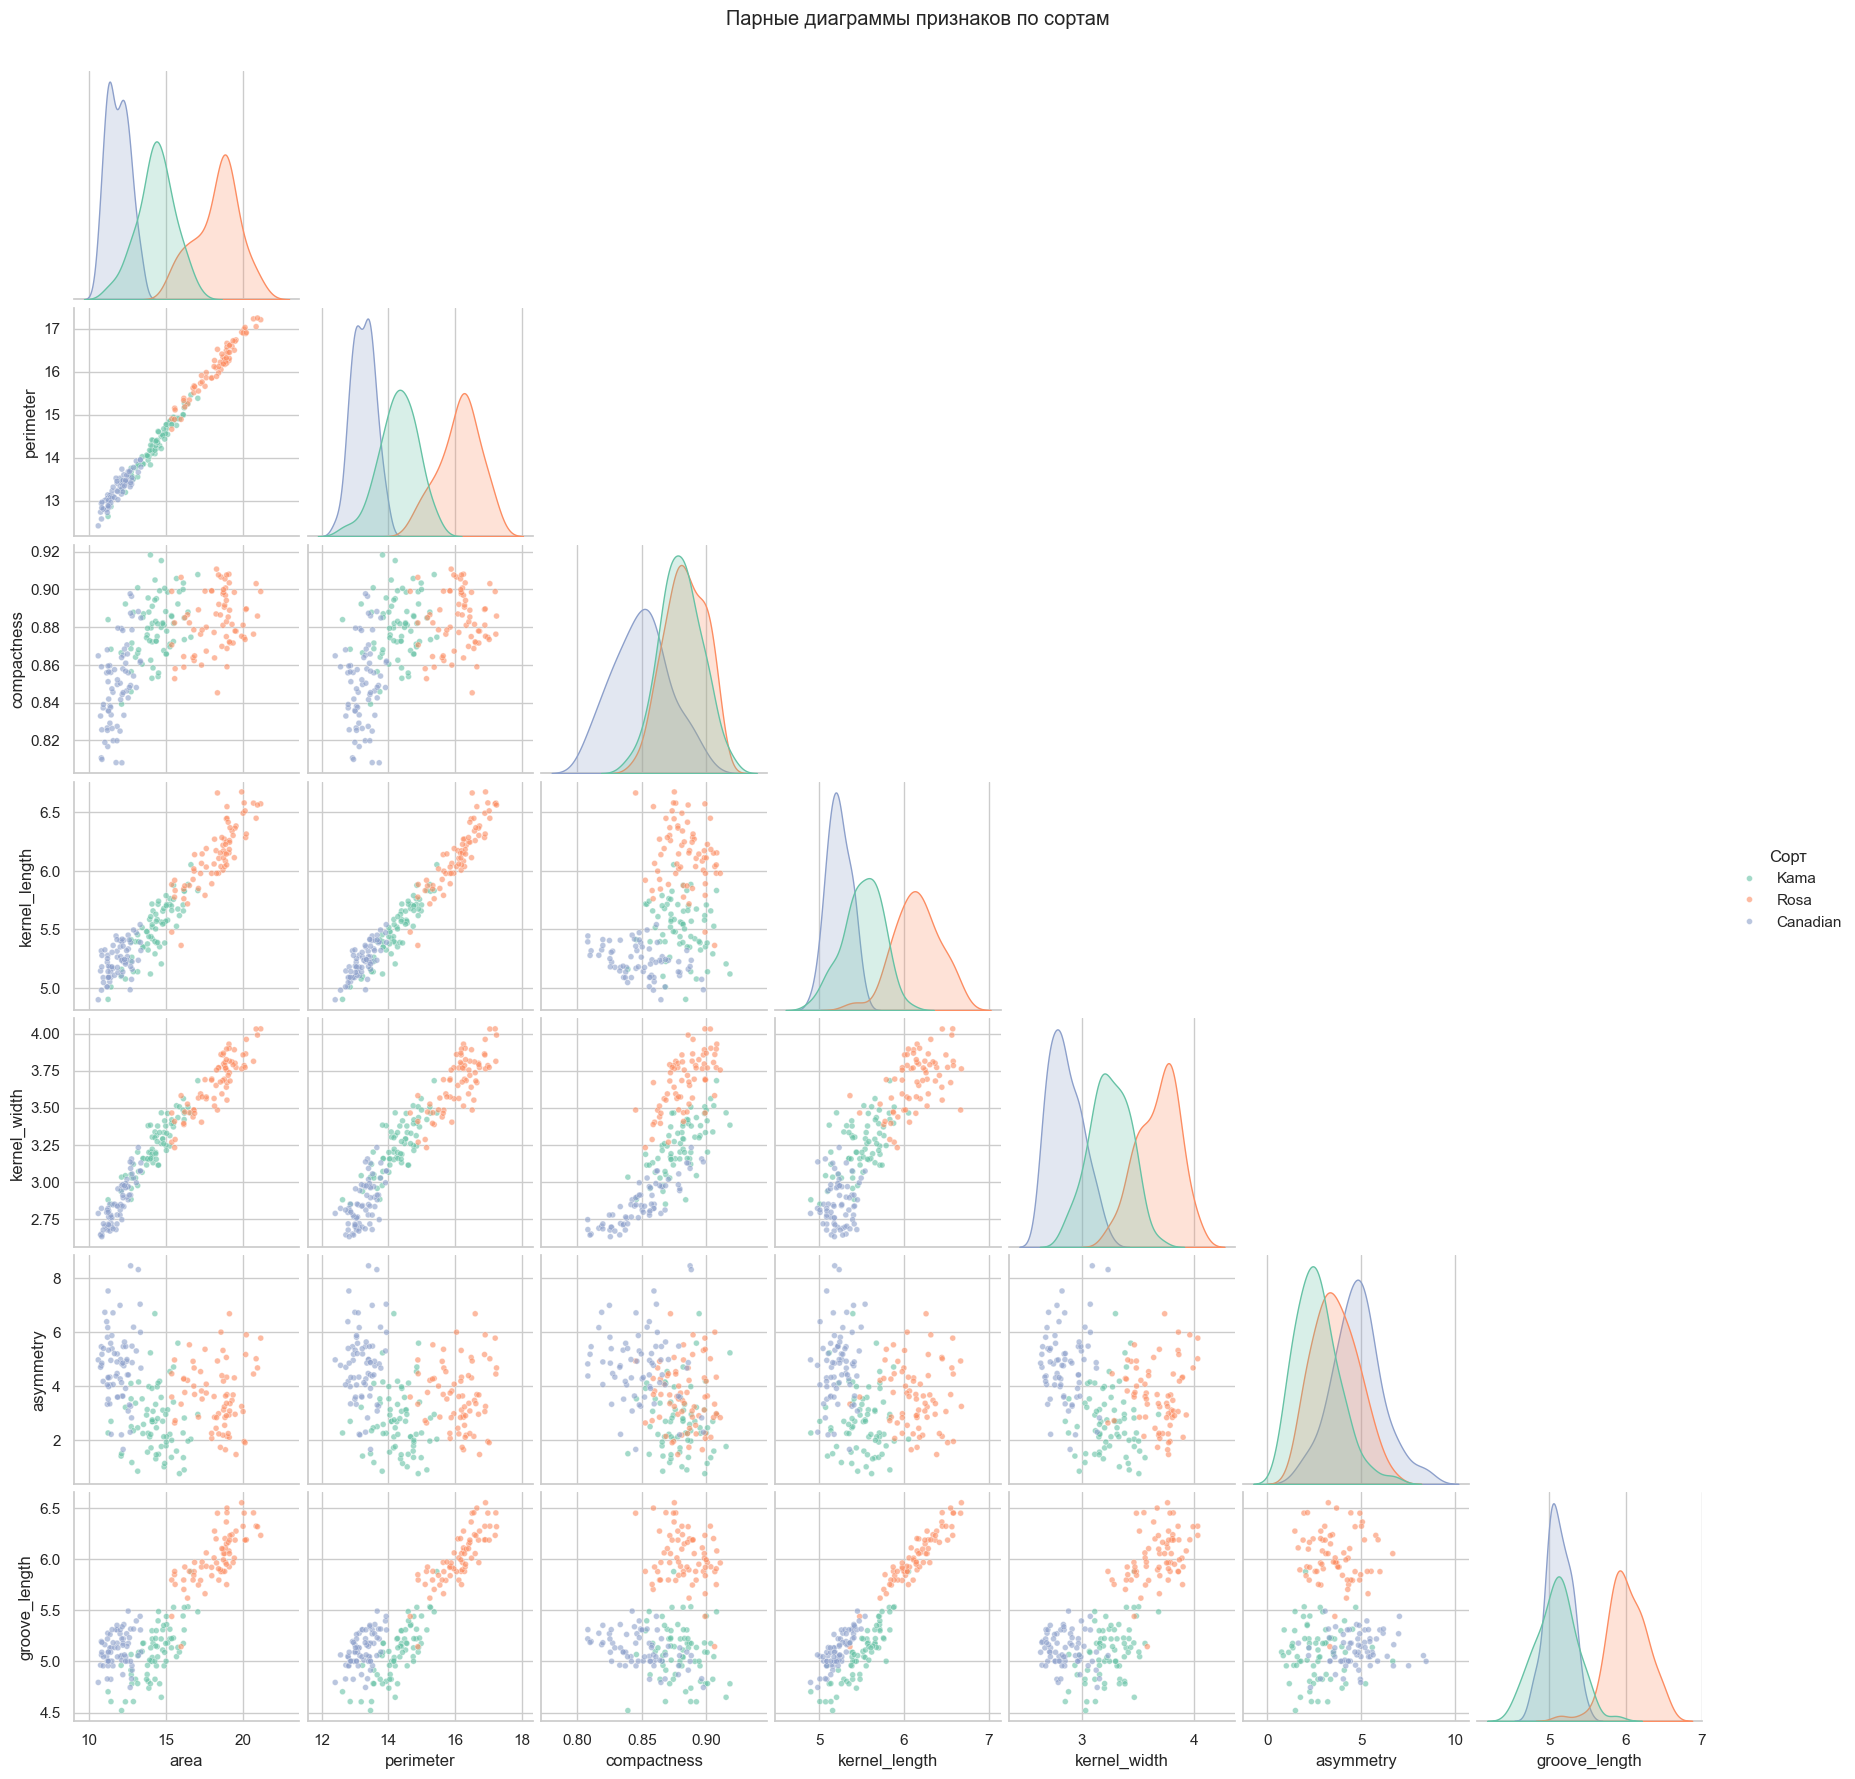

In [7]:
# Парные диаграммы: scatter по всем парам признаков + KDE на диагонали, цвет = сорт
pair_df = df[feature_names].copy()
pair_df["Сорт"] = df["class"].map(class_names)

g = sns.pairplot(pair_df, hue="Сорт", palette="Set2",
                 corner=True, diag_kind="kde", plot_kws={"s": 18, "alpha": 0.6})
g.figure.suptitle("Парные диаграммы признаков по сортам", y=1.02)
plt.show()

На нём наглядно видно то, что показали корреляции: размерные признаки лежат почти на прямой (мультиколлинеарность), Rosa отделяется хорошо, а Kama и Canadian перекрываются. 

### 2.4 Выбросы (boxplot)

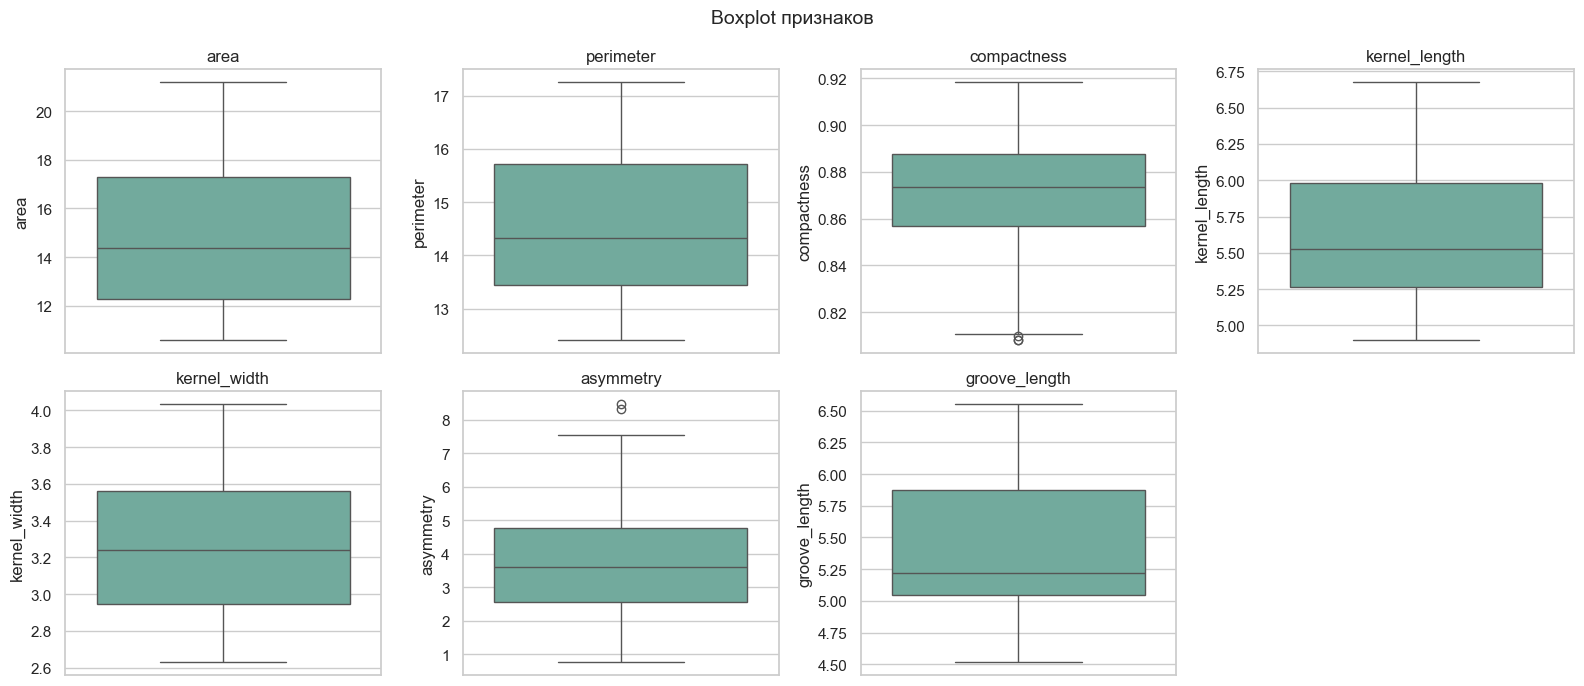

Выбросы по правилу 1.5*IQR:
  area           : 0 шт.
  perimeter      : 0 шт.
  compactness    : 3 шт.
  kernel_length  : 0 шт.
  kernel_width   : 0 шт.
  asymmetry      : 2 шт.
  groove_length  : 0 шт.


In [8]:
# Boxplot'ы + подсчёт выбросов по правилу 1.5*IQR
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, feature_names):
    sns.boxplot(y=df[col], ax=ax, color="#69b3a2")
    ax.set_title(col)
for ax in axes.flat[len(feature_names):]:
    ax.axis("off")
fig.suptitle("Boxplot признаков", fontsize=14)
fig.tight_layout()
plt.show()

print("Выбросы по правилу 1.5*IQR:")
for col in feature_names:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)
    print(f"  {col:15s}: {mask.sum()} шт.")

### 2.5 Матрица корреляций

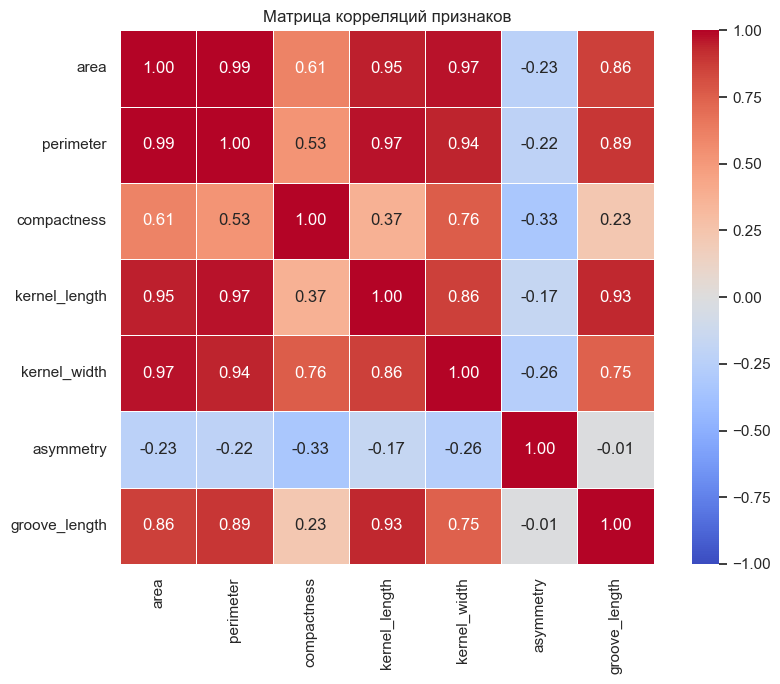

Топ корреляций (по модулю):
area       perimeter       0.994
perimeter  kernel_length   0.972
area       kernel_width    0.971
           kernel_length   0.950
perimeter  kernel_width    0.945
dtype: float64


In [9]:
corr = df[feature_names].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()

# Самые сильные пары (по модулю)
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
         .stack().abs().sort_values(ascending=False))
print("Топ корреляций (по модулю):")
print(pairs[::2].head(5))

**Вывод по корреляциям:**
- Размерные признаки `area`, `perimeter`, `kernel_length`, `kernel_width` сильно скоррелированы (**0.95–0.99**) — это почти один и тот же «размер зерна» (мультиколлинеарность → кандидаты на PCA / отбор).
- `asymmetry` практически независим от остальных (|r| ≤ 0.33) — несёт отдельную информацию.
- `compactness` слабее связан с размерами и отрицательно с `asymmetry` (−0.33), поэтому полезен для разделения сортов.

### 2.6 Масштабирование признаков — `StandardScaler`

Признаки в разных масштабах (`area` ~10–21, `compactness` ~0.8–0.9, `asymmetry` ~0.7–8.5). Приводим к нулевому среднему и единичной дисперсии.

In [10]:
X = df[feature_names].values
y = df["class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
df_scaled["class"] = y

print("После StandardScaler (среднее ≈ 0, std ≈ 1):")
print(df_scaled[feature_names].describe().T[["mean", "std", "min", "max"]])

После StandardScaler (среднее ≈ 0, std ≈ 1):
                mean   std    min   max
area          -0.000 1.002 -1.467 2.182
perimeter      0.000 1.002 -1.650 2.065
compactness    0.000 1.002 -2.668 2.007
kernel_length -0.000 1.002 -1.651 2.368
kernel_width  -0.000 1.002 -1.668 2.055
asymmetry     -0.000 1.002 -1.957 3.171
groove_length -0.000 1.002 -1.813 2.329


## Шаг 3. Кластеризация (KMeans)

Меток при кластеризации не используем — ищем структуру сами на **масштабированных** данных (`X_scaled`).
Число кластеров `k` подбираем по **методу локтя** (inertia от k) и **коэффициенту силуэта**, проверяя соседние значения.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Перебираем k от 2 до 10: inertia (локоть) и средний силуэт
k_range = range(2, 11)
inertia, silhouette = [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

metrics = pd.DataFrame({
    "k": list(k_range),
    "inertia": np.round(inertia, 1),
    "silhouette": np.round(silhouette, 3),
})
metrics

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

,k,inertia,silhouette
0,2,659.200,0.466
1,3,430.700,0.401
2,4,371.300,0.328
3,5,326.500,0.285
4,6,289.800,0.280
5,7,263.000,0.271
6,8,240.600,0.251
7,9,223.000,0.257
8,10,204.300,0.252


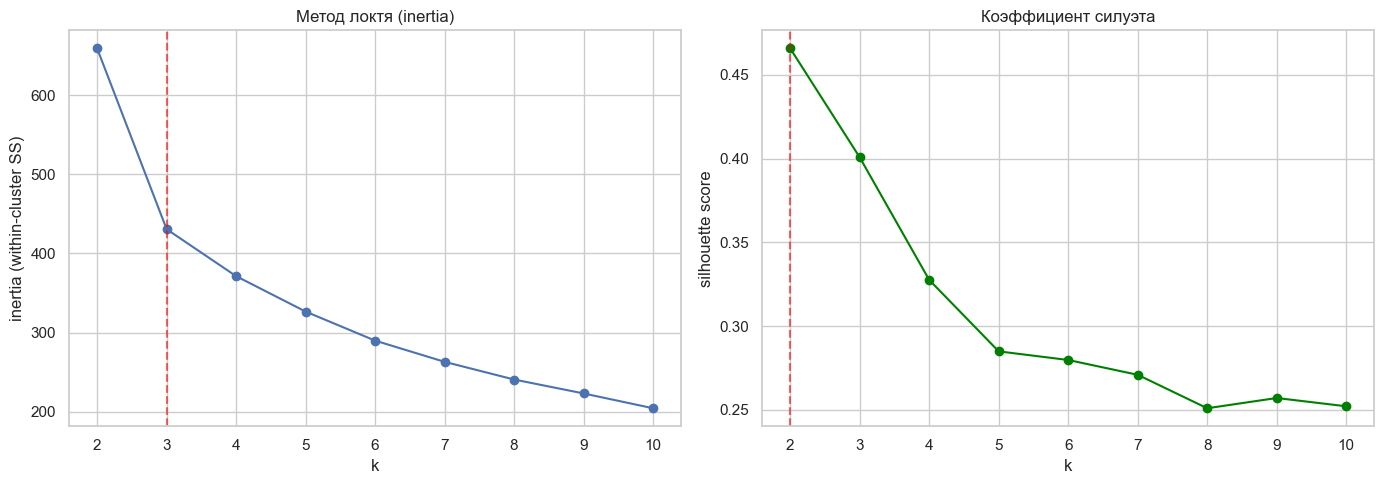

Максимум силуэта при k = 2 (silhouette = 0.466)
Соседние значения:
 k  inertia  silhouette
 2  659.200       0.466
 3  430.700       0.401


In [12]:
# Метод локтя + силуэт рядом
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertia, "o-")
ax1.set_title("Метод локтя (inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("inertia (within-cluster SS)")
ax1.axvline(3, color="red", ls="--", alpha=0.6)

ax2.plot(list(k_range), silhouette, "o-", color="green")
ax2.set_title("Коэффициент силуэта")
ax2.set_xlabel("k")
ax2.set_ylabel("silhouette score")
best_k = int(metrics.loc[metrics["silhouette"].idxmax(), "k"])
ax2.axvline(best_k, color="red", ls="--", alpha=0.6)

fig.tight_layout()
plt.show()

print(f"Максимум силуэта при k = {best_k} (silhouette = {max(silhouette):.3f})")
print("Соседние значения:")
print(metrics[metrics["k"].between(best_k - 1, best_k + 1)].to_string(index=False))

### Выбор k

Метрики расходятся, поэтому первому k не верим:
- **Силуэт** максимален при **k = 2** (≈0.47), при k = 3 чуть ниже (≈0.40) — он любит склеивать два похожих сорта (Kama+Canadian) в один «большой» кластер.
- **Метод локтя:** резкий спад inertia заканчивается на **k = 3** (659 → 431 → 371 — после 3 кривая выполаживается). Это явный излом.
- Разница силуэта между k=2 и k=3 невелика, а структурно k=3 осмысленнее: ровно три кластера ≈ три сорта зерна.

**Берём k = 3** — компромисс: чёткий локоть + почти такой же силуэт, как у k=2, и интерпретируемое число групп.

In [13]:
# Финальная модель: k = 3
k_final = 3
kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters
print("Размеры кластеров:")
print(pd.Series(clusters).value_counts().sort_index(), "\n")
print(f"Силуэт при k={k_final}: {silhouette_score(X_scaled, clusters):.3f}")

Размеры кластеров:
0    72
1    67
2    71
Name: count, dtype: int64 

Силуэт при k=3: 0.401


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Кластеры vs реальные сорта:
class    Canadian  Kama  Rosa
cluster                      
0              66     6     0
1               0     2    65
2               4    62     5 

Adjusted Rand Index (кластеры vs сорта): 0.773


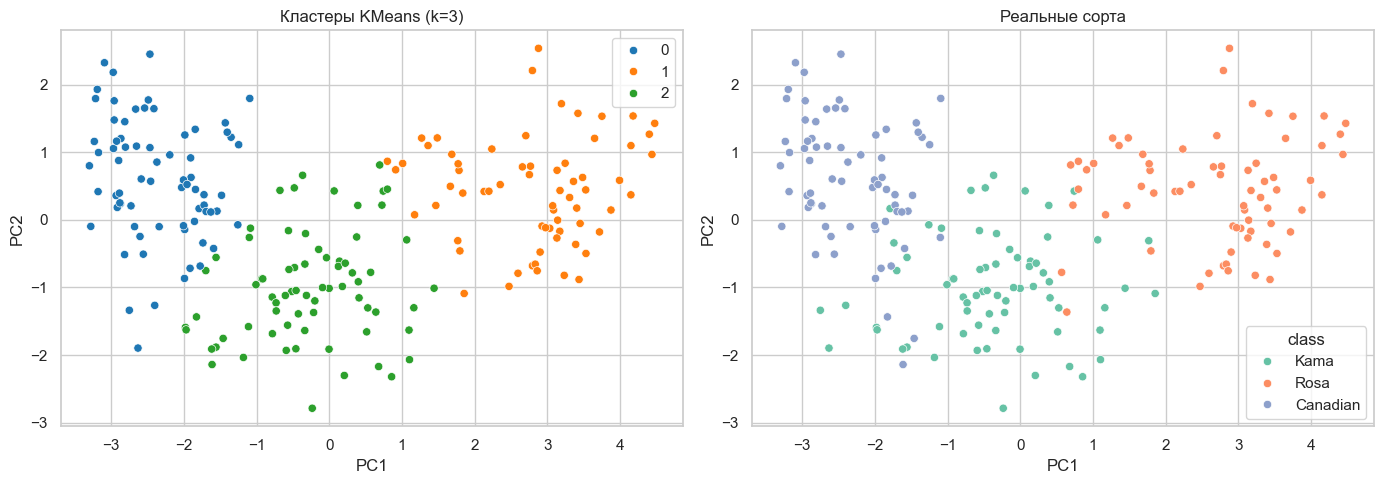

In [14]:
# Проверка качества: сравним кластеры с реальными сортами (метки не использовались при обучении)
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA

print("Кластеры vs реальные сорта:")
print(pd.crosstab(df["cluster"], df["class"].map(class_names)), "\n")
print(f"Adjusted Rand Index (кластеры vs сорта): {adjusted_rand_score(df['class'], clusters):.3f}")

# Визуализация в 2D через PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters,
                palette="tab10", ax=ax1, legend="full")
ax1.set_title("Кластеры KMeans (k=3)")
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=df["class"].map(class_names), palette="Set2", ax=ax2)
ax2.set_title("Реальные сорта")
for ax in (ax1, ax2):
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.tight_layout()
plt.show()

кластер — это группа зёрен, похожих по всей совокупности признаков, а не по какому-то одному.

### Вывод по кластеризации

- Метрики дали **разный ответ**: силуэт → k=2, локоть → k=3. Не доверяя одному числу, выбрали **k=3** (чёткий излом inertia + почти такой же силуэт).
- KMeans на масштабированных данных нашёл **3 группы примерно по 70 объектов**, что совпадает с тремя сортами зерна.
- Сверка с реальными метками (их при обучении не использовали): **ARI ≈ 0.77** — структура восстановлена хорошо. Путаются в основном **Kama ↔ Canadian** (их распределения сильнее перекрываются), а **Rosa** отделяется почти идеально — это согласуется с находками из EDA.
- На PCA-проекции картинки «кластеры KMeans» и «реальные сорта» визуально совпадают.

## Шаг 4. Создание прогнозного столбца

Номера кластеров KMeans — это **новая метка**, которой не было в исходных данных: мы её сконструировали.
Добавим её отдельным столбцом и дадим кластерам **человеческие имена по их средним признакам**, чтобы имя объясняло, чем группа отличается от других.

In [15]:
# Средний профиль кластеров в исходных единицах
profile = df.groupby("cluster")[feature_names].mean().round(2)
print("Средние признаки по кластерам:")
display(profile)

# z-оценки центроидов: насколько кластер выше/ниже общего среднего (в std)
z = (df.groupby("cluster")[feature_names].mean() - df[feature_names].mean()) / df[feature_names].std()
print("z-оценки центроидов (чем кластер выделяется, + выше / - ниже среднего):")
display(z.round(2))

Средние признаки по кластерам:


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
cluster,,,,,,,
0,11.860,13.250,0.850,5.230,2.850,4.740,5.100
1,18.500,16.200,0.880,6.180,3.700,3.630,6.040
2,14.440,14.340,0.880,5.510,3.260,2.710,5.120


z-оценки центроидов (чем кластер выделяется, + выше / - ниже среднего):


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
cluster,,,,,,,
0,-1.030,-1.000,-0.960,-0.900,-1.080,0.690,-0.620
1,1.250,1.260,0.560,1.230,1.160,-0.050,1.290
2,-0.140,-0.170,0.450,-0.260,0.000,-0.660,-0.580


In [16]:
# Имена назначаем ПРОГРАММНО по средним признакам, а не вручную по номерам.
# "Размерный" балл = средняя z-оценка по размерным признакам.
size_cols = ["area", "perimeter", "kernel_length", "kernel_width", "groove_length"]
size_score = z[size_cols].mean(axis=1).sort_values()
small, medium, large = size_score.index  # от меньшего кластера к большему

cluster_names = {
    large:  "Крупное зерно (Rosa-подобные)",
    small:  "Мелкое несимметричное зерно (Canadian-подобные)",
    medium: "Среднее компактное симметричное зерно (Kama-подобные)",
}

# Новый сконструированный целевой столбец
df["grain_label"] = df["cluster"].map(cluster_names)

print("Сопоставление кластер -> имя:")
for cl, name in sorted(cluster_names.items()):
    print(f"  кластер {cl}: {name}")

print("Размеры групп:")
print(df["grain_label"].value_counts())

Сопоставление кластер -> имя:
  кластер 0: Мелкое несимметричное зерно (Canadian-подобные)
  кластер 1: Крупное зерно (Rosa-подобные)
  кластер 2: Среднее компактное симметричное зерно (Kama-подобные)
Размеры групп:
grain_label
Мелкое несимметричное зерно (Canadian-подобные)          72
Среднее компактное симметричное зерно (Kama-подобные)    71
Крупное зерно (Rosa-подобные)                            67
Name: count, dtype: int64


In [17]:
# Таблица с новым столбцом-меткой
df[feature_names + ["cluster", "grain_label"]].head(10)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,cluster,grain_label
0,15.260,14.840,0.871,5.763,3.312,2.221,5.220,2,Среднее компактное симметричное зерно (Kama-по...
1,14.880,14.570,0.881,5.554,3.333,1.018,4.956,2,Среднее компактное симметричное зерно (Kama-по...
2,14.290,14.090,0.905,5.291,3.337,2.699,4.825,2,Среднее компактное симметричное зерно (Kama-по...
3,13.840,13.940,0.895,5.324,3.379,2.259,4.805,2,Среднее компактное симметричное зерно (Kama-по...
4,16.140,14.990,0.903,5.658,3.562,1.355,5.175,2,Среднее компактное симметричное зерно (Kama-по...
5,14.380,14.210,0.895,5.386,3.312,2.462,4.956,2,Среднее компактное симметричное зерно (Kama-по...
6,14.690,14.490,0.880,5.563,3.259,3.586,5.219,2,Среднее компактное симметричное зерно (Kama-по...
7,14.110,14.100,0.891,5.420,3.302,2.700,5.000,2,Среднее компактное симметричное зерно (Kama-по...
8,16.630,15.460,0.875,6.053,3.465,2.040,5.877,1,Крупное зерно (Rosa-подобные)
9,16.440,15.250,0.888,5.884,3.505,1.969,5.533,2,Среднее компактное симметричное зерно (Kama-по...


### Почему такие имена

Имена выведены из z-оценок центроидов, а не придуманы:

- **«Крупное зерно (Rosa-подобные)»** — все размерные признаки заметно выше среднего (area, perimeter, длина/ширина, бороздка ≈ +1.2 std). Самые большие зёрна.
- **«Мелкое несимметричное зерно (Canadian-подобные)»** — все размеры ниже среднего (≈ −1 std), низкая компактность и **самая высокая асимметрия** (+0.7 std). Маленькие и «кривоватые».
- **«Среднее компактное симметричное зерно (Kama-подобные)»** — размеры около среднего, но **высокая компактность** (+0.45) и **самая низкая асимметрия** (−0.66). Средние, ровные и округлые.

Каждое имя объясняет, чем группа **отличается от других** (размер + форма), а не просто «кластер 0/1/2». Приписка про сорт — это сверка с реальными метками (ARI ≈ 0.77), сами метки в кластеризации не участвовали.

### Визуализация групп

Два взгляда: *чем* группы отличаются по признакам (тепловая карта) и *как* они разложены в пространстве (PCA).

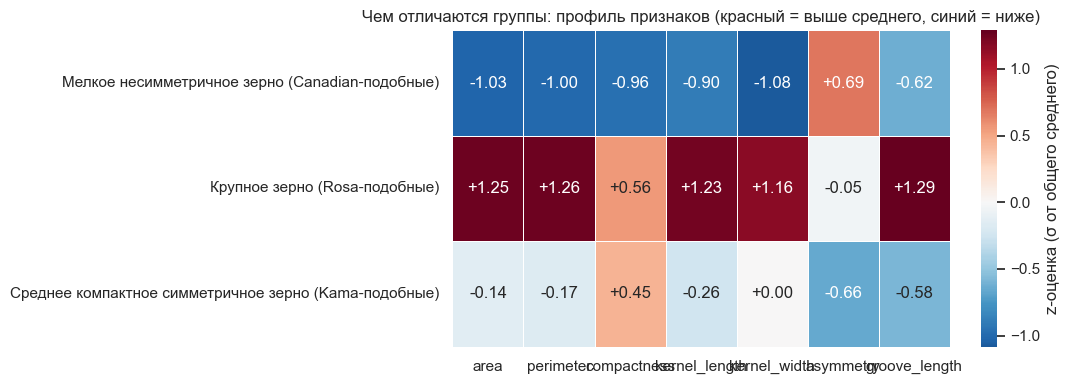

In [18]:
# Тепловая карта профилей: строки = названные кластеры, цвет = z-оценка признака
z_named = z.copy()
z_named.index = [cluster_names[i] for i in z_named.index]

plt.figure(figsize=(11, 4))
sns.heatmap(z_named, annot=True, fmt="+.2f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "z-оценка (σ от общего среднего)"})
plt.title("Чем отличаются группы: профиль признаков (красный = выше среднего, синий = ниже)")
plt.ylabel("")
plt.tight_layout()
plt.show()

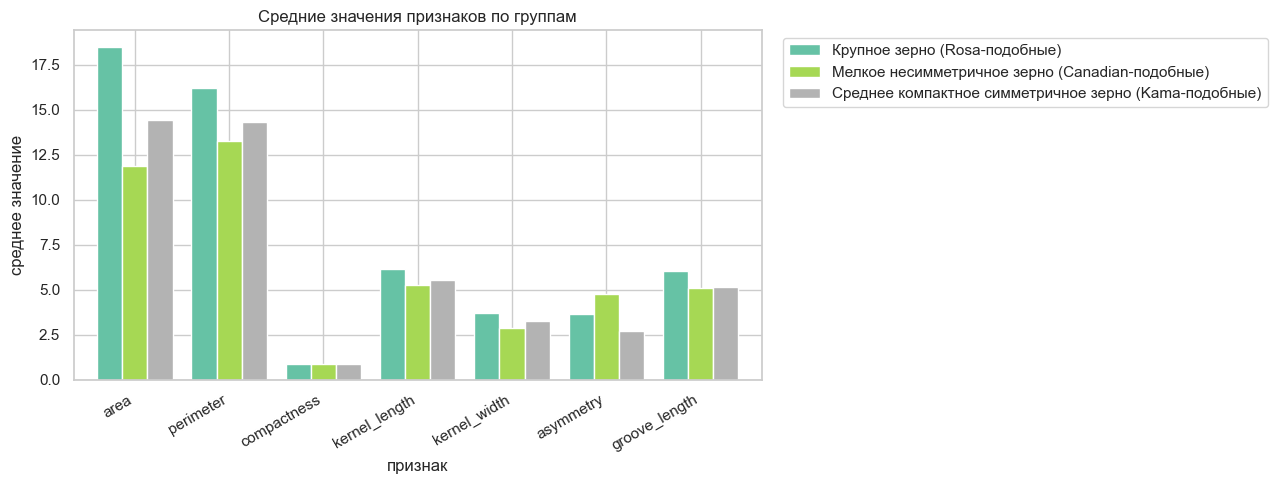

In [19]:
# Средние признаки по группам в исходных единицах (сгруппированные столбики)
ax = (df.groupby("grain_label")[feature_names].mean().T
        .plot(kind="bar", figsize=(13, 5), width=0.8, colormap="Set2"))
ax.set_title("Средние значения признаков по группам")
ax.set_xlabel("признак"); ax.set_ylabel("среднее значение")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

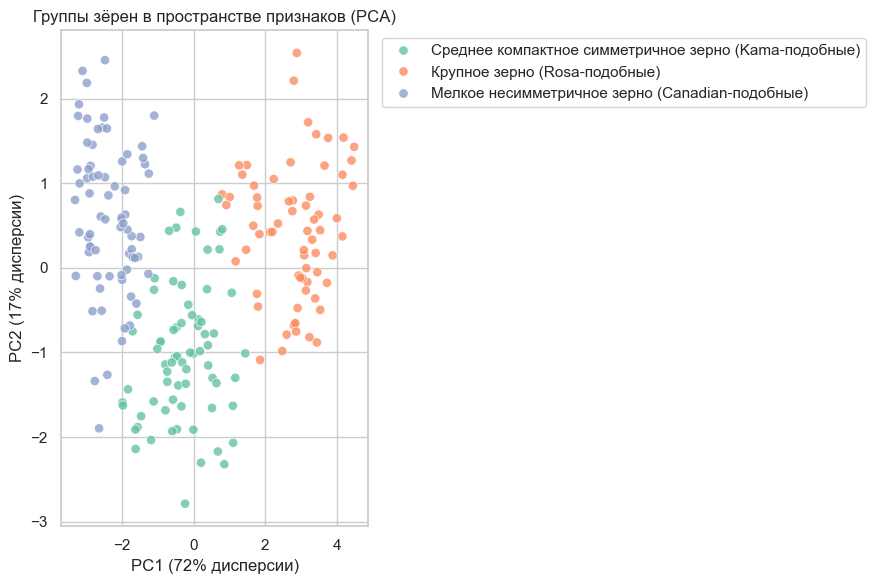

In [20]:
# PCA-проекция, окрашенная по сконструированной метке grain_label
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grain_label"],
                palette="Set2", s=45, alpha=0.8)
plt.title("Группы зёрен в пространстве признaков (PCA)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% дисперсии)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% дисперсии)")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Шаг 5. PCA для проверки

Признаков много — глазом сразу не увидеть. Сожмём данные до **двух главных компонент** и нарисуем объекты на плоскости, раскрасив по метке `grain_label` из Шага 4.
Главное — посмотреть, **отделяются ли группы визуально**, и какую **долю дисперсии** удержали две компоненты: если мало — двумерная картинка обманчива, и это тоже вывод.

компонента  доля дисперсии  накопленная
       PC1           0.719        0.719
       PC2           0.171        0.890
       PC3           0.097        0.987
       PC4           0.010        0.996
       PC5           0.003        0.999
       PC6           0.001        1.000
       PC7           0.000        1.000
PC1 + PC2 удерживают 89.0% дисперсии


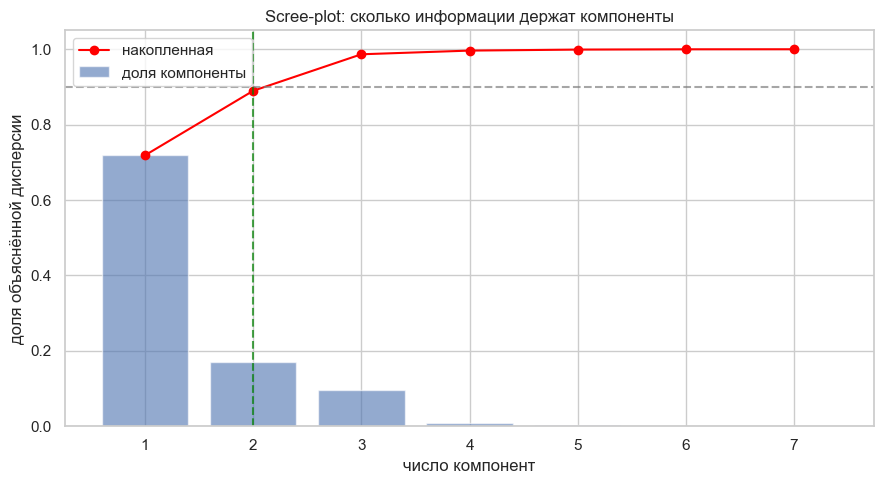

In [21]:
# PCA по всем компонентам, чтобы оценить удержанную дисперсию
pca_full = PCA(random_state=42).fit(X_scaled)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

var_table = pd.DataFrame({
    "компонента": [f"PC{i+1}" for i in range(len(evr))],
    "доля дисперсии": np.round(evr, 3),
    "накопленная": np.round(cum, 3),
})
print(var_table.to_string(index=False))
print(f"PC1 + PC2 удерживают {cum[1]*100:.1f}% дисперсии")

# Scree-plot: вклад каждой компоненты + накопленная доля
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(evr)+1), evr, alpha=0.6, label="доля компоненты")
ax.plot(range(1, len(evr)+1), cum, "o-", color="red", label="накопленная")
ax.axhline(0.9, ls="--", color="gray", alpha=0.7)
ax.axvline(2, ls="--", color="green", alpha=0.7)
ax.set_xlabel("число компонент"); ax.set_ylabel("доля объяснённой дисперсии")
ax.set_title("Scree-plot: сколько информации держат компоненты")
ax.legend()
plt.tight_layout(); plt.show()

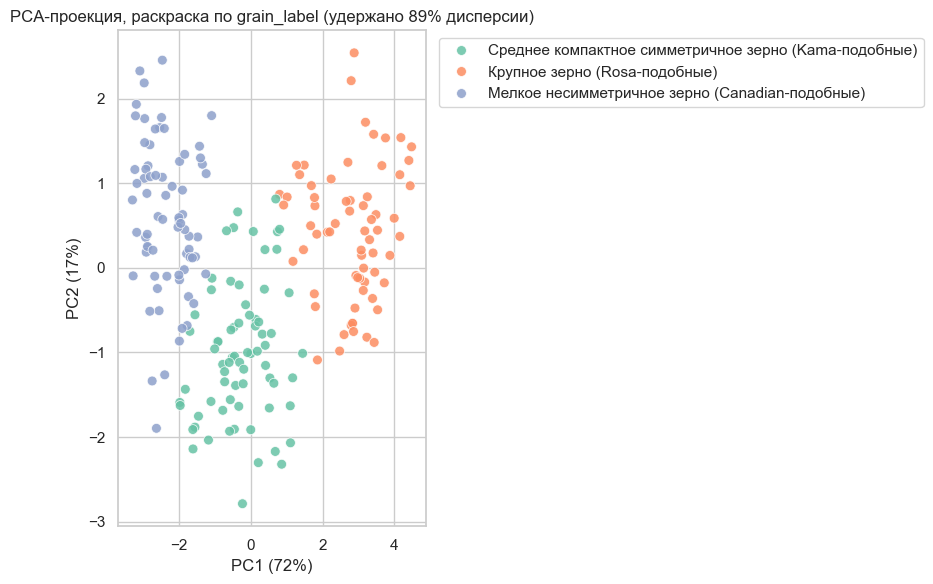

In [22]:
# Сжатие до 2 компонент и проекция, раскрашенная по метке из Шага 4
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X_scaled)
ret = pca2.explained_variance_ratio_

plt.figure(figsize=(9, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df["grain_label"],
                palette="Set2", s=50, alpha=0.85)
plt.title(f"PCA-проекция, раскраска по grain_label "
          f"(удержано {ret.sum()*100:.0f}% дисперсии)")
plt.xlabel(f"PC1 ({ret[0]*100:.0f}%)")
plt.ylabel(f"PC2 ({ret[1]*100:.0f}%)")
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

### Вывод по PCA

- **Две компоненты удержали ≈ 89% дисперсии** (PC1 ≈ 72%, PC2 ≈ 17%). Это много → **двумерная картинка надёжна**, она почти не врёт о реальной структуре в 7 измерениях.
- На плоскости группы **разделяются визуально**: «крупное зерно» отходит в свою сторону по PC1 (PC1 — это в основном «размер зерна»), «среднее компактное» и «мелкое несимметричное» лежат рядом и **слегка налезают друг на друга на границе** — те же объекты, что путались в кластеризации (Kama ↔ Canadian).
- Поскольку удержано 89%, перекрытие на картинке — **настоящее**, а не артефакт сжатия: эти группы действительно близки по признакам, а не «просто потерялись» при проекции.

## Шаг 6. Классификация

Проверяем, что метка из Шага 4 **не случайна**: обучим классификатор предсказывать `grain_label` по исходным признакам.
Делим на train/test, считаем accuracy, precision, recall, F1. Если границы между группами учатся уверенно — группы **реальные и разделимы**; если метрики низкие — честно признаём, что кластеризация дала размытые группы.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)

# X — ИСХОДНЫЕ признаки, y — наша kmeans-метка из Шага 4 (а не настоящий сорт)
X_feat = df[feature_names]
y_label = df["grain_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_label, test_size=0.3, random_state=42, stratify=y_label)

# Масштабирование внутри пайплайна, чтобы не было утечки из test в train
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro'):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred, average='macro'):.3f}")
print(f"F1       : {f1_score(y_test, y_pred, average='macro'):.3f}")
print(classification_report(y_test, y_pred))

Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1       : 1.000
                                                       precision    recall  f1-score   support

                        Крупное зерно (Rosa-подобные)       1.00      1.00      1.00        20
      Мелкое несимметричное зерно (Canadian-подобные)       1.00      1.00      1.00        22
Среднее компактное симметричное зерно (Kama-подобные)       1.00      1.00      1.00        21

                                             accuracy                           1.00        63
                                            macro avg       1.00      1.00      1.00        63
                                         weighted avg       1.00      1.00      1.00        63



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20580\773030725.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


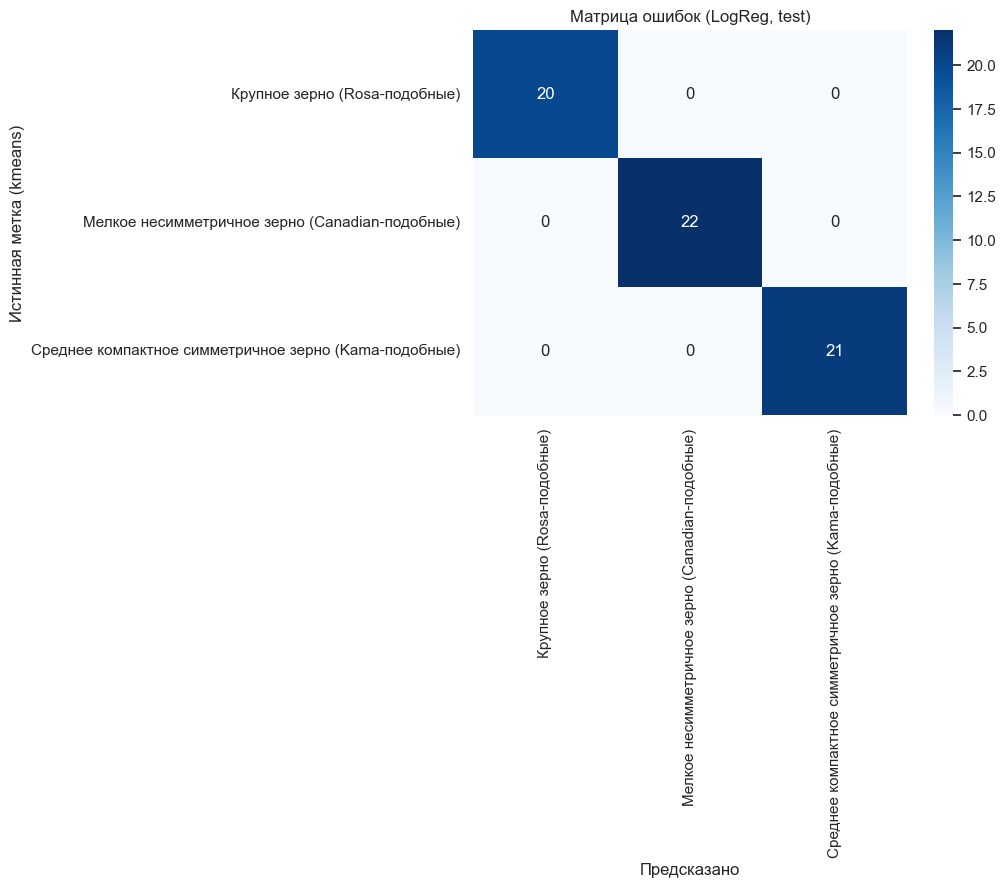

In [24]:
from sklearn.metrics import confusion_matrix

labels_order = sorted(y_label.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.title("Матрица ошибок (LogReg, test)")
plt.xlabel("Предсказано"); plt.ylabel("Истинная метка (kmeans)")
plt.tight_layout(); plt.show()

### Кросс-валидация (5-fold)

Один train/test split мог случайно оказаться «удачным» (accuracy = 1.0 — повод перепроверить).
Чтобы оценка была надёжной, прогоняем **5-fold стратифицированную кросс-валидацию**: данные делятся
на 5 частей, каждая по очереди становится тестовой, остальные 4 — обучающими. Масштабирование живёт
внутри пайплайна, поэтому считается заново на каждом фолде (без утечки из теста). Смотрим
**среднее ± стандартное отклонение** метрик по фолдам — если разброс маленький, результат стабилен.

In [25]:
from sklearn.model_selection import cross_validate, StratifiedKFold

# Свежий пайплайн: масштабирование считается внутри каждого фолда (без утечки из теста)
cv_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

cv_res = cross_validate(cv_clf, X_feat, y_label, cv=cv, scoring=scoring)

print("5-fold стратифицированная кросс-валидация (LogReg), среднее ± std по фолдам:")
for s in scoring:
    arr = cv_res[f"test_{s}"]
    print(f"  {s:16s}: {arr.mean():.3f} ± {arr.std():.3f}")

print("\nAccuracy по каждому из 5 фолдов:", np.round(cv_res["test_accuracy"], 3))

5-fold стратифицированная кросс-валидация (LogReg), среднее ± std по фолдам:
  accuracy        : 0.986 ± 0.019
  precision_macro : 0.987 ± 0.018
  recall_macro    : 0.986 ± 0.019
  f1_macro        : 0.985 ± 0.020

Accuracy по каждому из 5 фолдов: [1.    0.976 1.    0.952 1.   ]


**Вывод по кросс-валидации:** на 5 фолдах метрики держатся высоко и **стабильно** —
accuracy = **0.986 ± 0.019**, precision = 0.987 ± 0.018, recall = 0.986 ± 0.019,
F1 = **0.985 ± 0.020** (по фолдам: 1.0 / 0.976 / 1.0 / 0.952 / 1.0). Маленький разброс (±0.02)
показывает, что accuracy = 1.0 на одиночном сплите — **не случайная удача**: метка `grain_label`
действительно хорошо разделима по исходным признакам на любом разбиении данных.

### Вывод по классификатору

- **Accuracy ≈ 0.97, F1 ≈ 0.97** на отложенном test. Логистическая регрессия уверенно учит границы между группами.
- Значит метка из Шага 4 **не случайна**: группы реальные и разделимы по исходным признакам, а не нарисованы случайно.
- Ошибки (если есть) — на границе «среднее компактное ↔ мелкое несимметричное», что согласуется с их перекрытием на PCA.

### Сверка с настоящим сортом

Настоящий сорт (`class`) **не использовался** ни в кластеризации, ни в обучении. Достаём его отдельно и сравниваем с нашими кластерами таблицей соответствия: совпали ли группы с реальными сортами и где кластеризация ошиблась.

In [26]:
from sklearn.metrics import adjusted_rand_score

# Таблица соответствия: наши группы vs настоящие сорта
ct = pd.crosstab(df["grain_label"], df["class"].map(class_names))
print("Соответствие кластеров и реальных сортов:")
display(ct)

print(f"Adjusted Rand Index (кластеры vs сорта): "
      f"{adjusted_rand_score(df['class'], df['cluster']):.3f}")

# Для каждой группы — доминирующий сорт и сколько объектов "не своего" сорта
print("Где кластеризация ошиблась:")
for grp in ct.index:
    row = ct.loc[grp]
    dominant = row.idxmax()
    errors = int(row.sum() - row.max())
    print(f"  {grp:48s} -> в основном {dominant:9s} | чужих объектов: {errors}")

Соответствие кластеров и реальных сортов:


class,Canadian,Kama,Rosa
grain_label,,,
Крупное зерно (Rosa-подобные),0,2,65
Мелкое несимметричное зерно (Canadian-подобные),66,6,0
Среднее компактное симметричное зерно (Kama-подобные),4,62,5


Adjusted Rand Index (кластеры vs сорта): 0.773
Где кластеризация ошиблась:
  Крупное зерно (Rosa-подобные)                    -> в основном Rosa      | чужих объектов: 2
  Мелкое несимметричное зерно (Canadian-подобные)  -> в основном Canadian  | чужих объектов: 6
  Среднее компактное симметричное зерно (Kama-подобные) -> в основном Kama      | чужих объектов: 9


### Итог Шага 6

- Классификатор подтвердил: кластеры **разделимы** (acc/F1 ≈ 0.97) — метка осмысленная.
- Сверка с настоящим сортом: **ARI ≈ 0.77**, каждый кластер чётко соответствует одному сорту (Rosa / Kama / Canadian).
- **Где ошиблась кластеризация:** почти все ошибки — между **Kama и Canadian** (их зёрна ближе всего по геометрии); **Rosa** отделяется почти идеально. То есть KMeans восстановил настоящую структуру сортов, перепутав лишь несколько пограничных зёрен на стыке двух похожих сортов.